In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

I will check the recombination rate map and phastcons file in thie notebook.

In [2]:
recomb_map = pd.read_csv("../data/hg38.recombAvg.bedGraph", sep="\t", names=["chrom", "start", "end", "recomb"])

<Axes: xlabel='length', ylabel='recomb'>

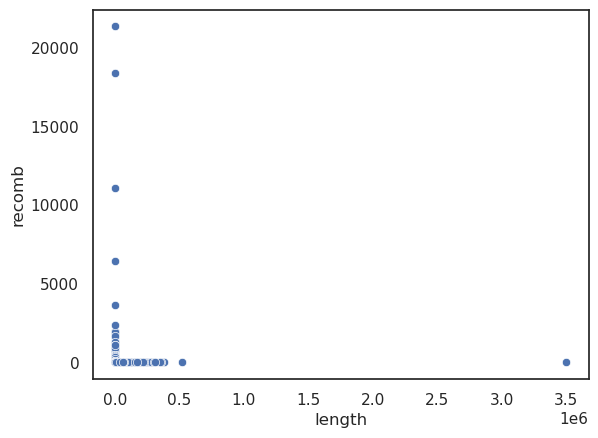

In [3]:
recomb_map["length"] = recomb_map.end-recomb_map.start
sns.scatterplot(recomb_map.loc[(recomb_map.chrom == "chrX")], x="length", y="recomb")

In [4]:
recomb_map.loc[recomb_map.chrom == "chrX"]

,chrom,start,end,recomb,length
1113583,chrX,3532526,3533229,2.641420e-01,703
1113584,chrX,3533229,3534231,1.352180e+00,1002
1113585,chrX,3534231,3580516,0.000000e+00,46285
1113586,chrX,3580516,3582267,6.668370e-14,1751
1113587,chrX,3582267,3582957,9.080830e-11,690
...,...,...,...,...,...
1137554,chrX,154496001,154664593,7.542680e-02,168592
1137555,chrX,154664593,154676196,2.530880e-22,11603
1137556,chrX,154676196,154680555,8.751390e-36,4359
1137557,chrX,154680555,154717327,2.145440e-39,36772


This seems a bit strange. Alternative check of https://www.science.org/doi/10.1126/science.aau1043#supplementary-materials datas2 (maternal recombination rate)

In [5]:
window2019 = pd.read_csv("../data/decode_maternal.tsv", skiprows=7, sep="\t")
window2019

,Chr,Begin,End,cMperMb,cM
0,chr1,1431813,1515567,2.585239e-02,0.002165
1,chr1,1515567,1530002,4.740767e-02,0.002850
2,chr1,1530002,1534402,1.700061e-03,0.002857
3,chr1,1534402,1538787,7.231869e-03,0.002889
4,chr1,1538787,1541864,7.787222e-06,0.002889
...,...,...,...,...,...
1146928,chrX,154496001,154664593,7.542684e-02,175.881960
1146929,chrX,154664593,154676196,2.530884e-22,175.881960
1146930,chrX,154676196,154680555,8.751389e-36,175.881960
1146931,chrX,154680555,154717327,2.145439e-39,175.881960


In [6]:
window2019["length"] = window2019.End-window2019.Begin
window2019["Chr"].unique()

array(['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21',
       'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9',
       'chrX'], dtype=object)

<Axes: xlabel='length', ylabel='cMperMb'>

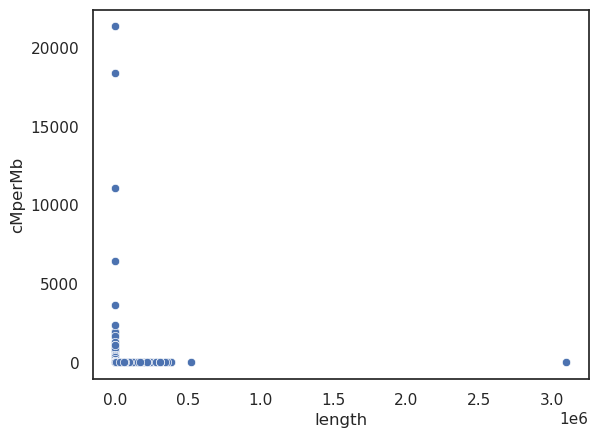

In [7]:
sns.scatterplot(window2019.loc[(window2019.Chr == "chrX")], x="length", y="cMperMb")

In [8]:
window2019.loc[window2019.length > 348421]

,Chr,Begin,End,cMperMb,cM,length
47934,chr1,121741467,125040127,5.304224e-10,181.658624,3298660
47947,chr1,125166622,129166486,6.733244e-03,181.692216,3999864
47949,chr1,129166622,133166486,6.733244e-03,181.719149,3999864
47951,chr1,133166622,137166486,6.733244e-03,181.746082,3999864
47953,chr1,137166622,141166486,6.733244e-03,181.773015,3999864
...,...,...,...,...,...,...
1133278,chrX,58094990,58477084,1.590265e-04,77.570198,382094
1133279,chrX,58477084,58999901,1.383680e-03,77.570922,522817
1133280,chrX,58999901,62094990,2.281433e-03,77.577983,3095089
1133281,chrX,62094990,62477084,2.281433e-03,77.578855,382094


Similar results. I will lift the decode maternal as its labelled better.

In [18]:
window_named = window2019.rename(columns={"Chr": "chrom", "Begin": "start", "End": "end"})[["chrom", "start", "end", "cMperMb"]]
window_named.to_csv("../data/recomb_bed.bed", sep="\t", index=False, header=False)

PhastCons conversion into a bed file of 10kb intervals.

In [7]:
c = 0
window_size = 10000
prob_list = []

c_l, start_l, end_l, stat_l, base_count_l = [], [], [], [], []


with open("../data/hg38.phastCons100way.bedGraph") as file:
    next_window = window_size
    current_chrom = "chr1"
    for line in file:
        stripped_list = line.strip().split("\t")
        # Generate stats and reset counts
        if int(stripped_list[2]) >= next_window or stripped_list[0] != current_chrom:
            if len(prob_list) > 0:
                c_l.append(current_chrom)
                start_l.append(next_window-window_size)
                end_l.append(next_window)
                stat_l.append(np.mean(prob_list))
                base_count_l.append(len(prob_list))
            # Reset list no matter what for good measure
            prob_list = []
            if stripped_list[0] != current_chrom:
                print("Finished", current_chrom)
                current_chrom = stripped_list[0]
                next_window = window_size
            else:
                next_window += window_size
        else:
            prob_list.append(float(stripped_list[3]))

Finished chr1
Finished chr10
Finished chr10_GL383545v1_alt
Finished chr10_GL383546v1_alt
Finished chr10_KI270824v1_alt
Finished chr10_KI270825v1_alt
Finished chr11
Finished chr11_GL383547v1_alt
Finished chr11_JH159136v1_alt
Finished chr11_JH159137v1_alt
Finished chr11_KI270721v1_random
Finished chr11_KI270826v1_alt
Finished chr11_KI270827v1_alt
Finished chr11_KI270829v1_alt
Finished chr11_KI270830v1_alt
Finished chr11_KI270831v1_alt
Finished chr11_KI270832v1_alt
Finished chr11_KI270902v1_alt
Finished chr11_KI270903v1_alt
Finished chr11_KI270927v1_alt
Finished chr12
Finished chr12_GL383549v1_alt
Finished chr12_GL383550v2_alt
Finished chr12_GL383551v1_alt
Finished chr12_GL383552v1_alt
Finished chr12_GL383553v2_alt
Finished chr12_GL877875v1_alt
Finished chr12_GL877876v1_alt
Finished chr12_KI270833v1_alt
Finished chr12_KI270834v1_alt
Finished chr12_KI270835v1_alt
Finished chr12_KI270836v1_alt
Finished chr12_KI270837v1_alt
Finished chr12_KI270904v1_alt
Finished chr13
Finished chr13_KI270838

Finished chr7_KI270803v1_alt
Finished chr7_KI270804v1_alt
Finished chr7_KI270805v1_alt
Finished chr7_KI270806v1_alt
Finished chr7_KI270807v1_alt
Finished chr7_KI270808v1_alt
Finished chr7_KI270809v1_alt
Finished chr7_KI270899v1_alt
Finished chr8
Finished chr8_KI270810v1_alt
Finished chr8_KI270811v1_alt
Finished chr8_KI270812v1_alt
Finished chr8_KI270813v1_alt
Finished chr8_KI270814v1_alt
Finished chr8_KI270815v1_alt
Finished chr8_KI270816v1_alt
Finished chr8_KI270817v1_alt
Finished chr8_KI270818v1_alt
Finished chr8_KI270819v1_alt
Finished chr8_KI270820v1_alt
Finished chr8_KI270821v1_alt
Finished chr8_KI270822v1_alt
Finished chr8_KI270900v1_alt
Finished chr8_KI270901v1_alt
Finished chr8_KI270926v1_alt
Finished chr9
Finished chr9_GL383539v1_alt
Finished chr9_GL383540v1_alt
Finished chr9_GL383541v1_alt
Finished chr9_GL383542v1_alt
Finished chr9_KI270717v1_random
Finished chr9_KI270718v1_random
Finished chr9_KI270719v1_random
Finished chr9_KI270720v1_random
Finished chr9_KI270823v1_alt
Fin

In [10]:
phastcons_df = pd.DataFrame({"chrom": c_l, "start": start_l, "end": end_l, "mean_phast": stat_l, "base_count": base_count_l})

In [11]:
phastcons_df["chrom"].unique()

array(['chr1', 'chr10', 'chr10_GL383545v1_alt', 'chr10_GL383546v1_alt',
       'chr10_KI270824v1_alt', 'chr10_KI270825v1_alt', 'chr11',
       'chr11_GL383547v1_alt', 'chr11_JH159136v1_alt',
       'chr11_JH159137v1_alt', 'chr11_KI270721v1_random',
       'chr11_KI270826v1_alt', 'chr11_KI270827v1_alt',
       'chr11_KI270829v1_alt', 'chr11_KI270830v1_alt',
       'chr11_KI270831v1_alt', 'chr11_KI270832v1_alt',
       'chr11_KI270902v1_alt', 'chr11_KI270903v1_alt',
       'chr11_KI270927v1_alt', 'chr12', 'chr12_GL383549v1_alt',
       'chr12_GL383550v2_alt', 'chr12_GL383551v1_alt',
       'chr12_GL383552v1_alt', 'chr12_GL383553v2_alt',
       'chr12_GL877875v1_alt', 'chr12_GL877876v1_alt',
       'chr12_KI270833v1_alt', 'chr12_KI270834v1_alt',
       'chr12_KI270835v1_alt', 'chr12_KI270836v1_alt',
       'chr12_KI270837v1_alt', 'chr12_KI270904v1_alt', 'chr13',
       'chr13_KI270838v1_alt', 'chr13_KI270839v1_alt',
       'chr13_KI270840v1_alt', 'chr13_KI270841v1_alt',
       'chr13_KI27

In [18]:
chr_list = ["chr{}".format(x) for x in list(range(1, 23)) + ["X"]]
phastcons_df.loc[(phastcons_df.chrom.isin(chr_list)) & (phastcons_df.base_count >= 5000)]

,chrom,start,end,mean_phast,base_count
2,chr1,30000,40000,0.106626,6770
3,chr1,40000,50000,0.090449,7388
4,chr1,50000,60000,0.077258,5439
5,chr1,60000,70000,0.116489,5410
6,chr1,70000,80000,0.110579,6634
...,...,...,...,...,...
295220,chrX,155980000,155990000,0.287374,8755
295221,chrX,155990000,156000000,0.158703,7565
295222,chrX,156000000,156010000,0.143692,5124
295223,chrX,156010000,156020000,0.097082,5516


In [17]:
phastcons_df

,chrom,start,end,mean_phast,base_count
0,chr1,10000,20000,0.208848,4097
1,chr1,20000,30000,0.079952,4700
2,chr1,30000,40000,0.106626,6770
3,chr1,40000,50000,0.090449,7388
4,chr1,50000,60000,0.077258,5439
...,...,...,...,...,...
297842,chrY,57160000,57170000,0.213639,8738
297843,chrY,57170000,57180000,0.282655,6453
297844,chrY,57180000,57190000,0.106320,6144
297845,chrY,57190000,57200000,0.127062,5674


<Axes: xlabel='mean_phast', ylabel='Count'>

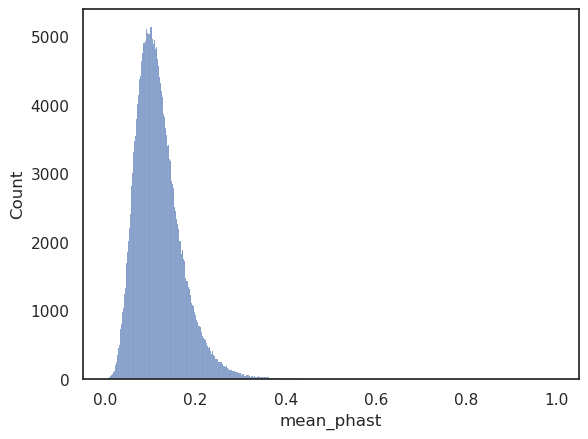

In [19]:
sns.histplot(phastcons_df.mean_phast)

In [20]:
phastcons_sub = phastcons_df.loc[(phastcons_df.chrom.isin(chr_list)) & (phastcons_df.base_count >= 5000)]
window_phast = phastcons_sub[["chrom", "start", "end", "mean_phast"]]
window_phast.to_csv("../data/phast_10kb.bed", sep="\t", index=False, header=False)

A quick check of lifted bed files.

In [24]:
pd.read_csv("../data/lifted_recomb.bed", sep="\t")

,chrCP068277.2,866173,877215,0.0258523873783976
0,chrCP068277.2,877247,878065,2.585239e-02
1,chrCP068277.2,878065,888015,2.585239e-02
2,chrCP068277.2,888016,903472,2.585239e-02
3,chrCP068277.2,903472,912225,2.585239e-02
4,chrCP068277.2,912358,950071,2.585239e-02
...,...,...,...,...
1857378,chrCP068255.2,152993037,152993938,2.079851e-39
1857379,chrCP068255.2,152993938,152998644,2.079851e-39
1857380,chrCP068255.2,152998644,153005429,2.079851e-39
1857381,chrCP068255.2,153005430,153006900,2.079851e-39


In [23]:
pd.read_csv("../data/hs1_lifted_recomb.bed", sep="\t")

,chr1,866173,877215,0.0258523873783976
0,chr1,877247,878065,2.585239e-02
1,chr1,878065,888015,2.585239e-02
2,chr1,888016,903472,2.585239e-02
3,chr1,903472,912225,2.585239e-02
4,chr1,912358,950071,2.585239e-02
...,...,...,...,...
1857378,chrX,152993037,152993938,2.079851e-39
1857379,chrX,152993938,152998644,2.079851e-39
1857380,chrX,152998644,153005429,2.079851e-39
1857381,chrX,153005430,153006900,2.079851e-39


In [26]:
pd.read_csv("../data/lifted_phast.bed", sep="\t")

,chrCP068267.2,21556,23579,0.10662599704579025
0,chrCP068267.2,23643,23734,0.106626
1,chrCP068267.2,23735,25149,0.106626
2,chrCP068267.2,25149,27970,0.106626
3,chrCP068267.2,27971,28510,0.106626
4,chrCP068267.2,28510,31619,0.106626
...,...,...,...,...
864709,chrCP068255.2,154249566,154253807,0.198317
864710,chrCP068255.2,154253808,154255136,0.198317
864711,chrCP068255.2,154255136,154256393,0.198317
864712,chrCP068255.2,154256393,154256713,0.198317


In [25]:
pd.read_csv("../data/hs1_lifted_phast.bed", sep="\t")

,chr11,21556,23579,0.10662599704579025
0,chr11,23643,23734,0.106626
1,chr11,23735,25149,0.106626
2,chr11,25149,27970,0.106626
3,chr11,27971,28510,0.106626
4,chr11,28510,31619,0.106626
...,...,...,...,...
864709,chrX,154249566,154253807,0.198317
864710,chrX,154253808,154255136,0.198317
864711,chrX,154255136,154256393,0.198317
864712,chrX,154256393,154256713,0.198317
